⚙️ Generating synthetic exon/intron FASTA files...
✅ Combined FASTA saved as labeled_data.fasta
✅ Sequences Loaded: 40
Label Distribution: Counter({'Coding (Exon)': 20, 'Non-Coding (Intron)': 20})

🚀 Training model...

🎯 Accuracy Achieved: 91.67%

Classification Report:
                      precision    recall  f1-score   support

      Coding (Exon)       1.00      0.83      0.91         6
Non-Coding (Intron)       0.86      1.00      0.92         6

           accuracy                           0.92        12
          macro avg       0.93      0.92      0.92        12
       weighted avg       0.93      0.92      0.92        12



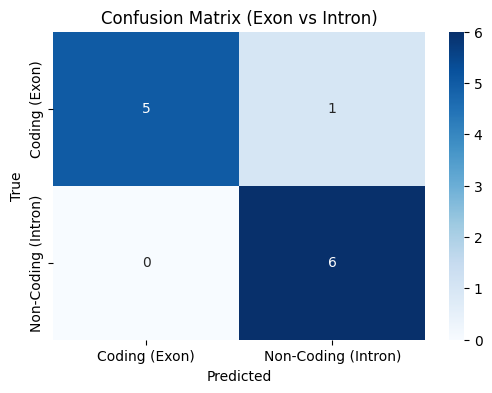

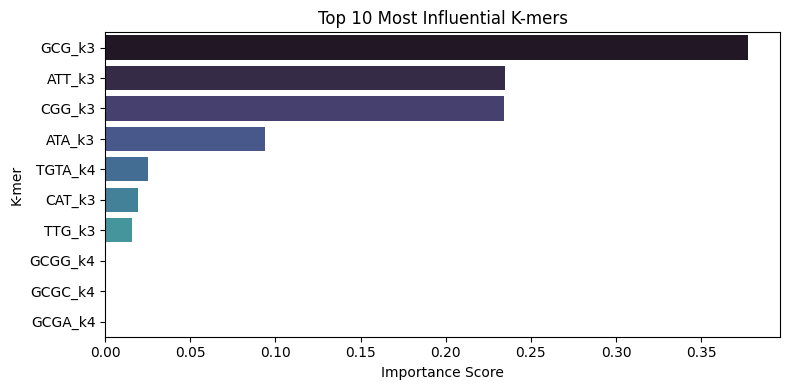


📈 Cross-Validation Accuracy (5-fold): 87.50% ± 11.18%

✅ Completed successfully! Use visuals & accuracy in your report.


In [9]:
# ============================================
# 🧬 EXON–INTRON CLASSIFIER (Final Version)
# ============================================
import os
import random
import re
import pandas as pd
import numpy as np
from collections import Counter
from itertools import product
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ===================================================
# 1️⃣ Synthetic FASTA Generation (if none exist)
# ===================================================
def random_dna(length, gc_bias=0.5):
    """Generate random DNA sequence with GC bias."""
    seq = ""
    for _ in range(length):
        if random.random() < gc_bias:
            seq += random.choice("GC")
        else:
            seq += random.choice("AT")
    return seq

if not os.path.exists("exEID_synthetic.fasta") or not os.path.exists("intrEID_synthetic.fasta"):
    print("⚙️ Generating synthetic exon/intron FASTA files...")
    exons = [random_dna(random.randint(120, 180), gc_bias=0.65) for _ in range(20)]
    introns = [random_dna(random.randint(200, 350), gc_bias=0.35) for _ in range(20)]

    with open("exEID_synthetic.fasta", "w") as f:
        for i, seq in enumerate(exons, start=1):
            f.write(f">Exon_{i}\n{seq}\n")

    with open("intrEID_synthetic.fasta", "w") as f:
        for i, seq in enumerate(introns, start=1):
            f.write(f">Intron_{i}\n{seq}\n")

# ===================================================
# 2️⃣ Combine into single labeled_data.fasta
# ===================================================
def combine_fasta(exon_file, intron_file, output_file="labeled_data.fasta"):
    with open(output_file, "w") as outfile:
        for fname in [exon_file, intron_file]:
            with open(fname) as infile:
                for line in infile:
                    outfile.write(line)
    print(f"✅ Combined FASTA saved as {output_file}")

combine_fasta("exEID.fasta", "intrEID.fasta")

# ===================================================
# 3️⃣ Load and label FASTA
# ===================================================
def load_and_label_fasta(file_path):
    sequences, labels, current_seq, current_label = [], [], "", None
    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if current_seq and current_label:
                    sequences.append(current_seq)
                    labels.append(current_label)
                match = re.search(r'(Exon|Intron)', line, re.IGNORECASE)
                current_label = "Coding (Exon)" if "exon" in match.group(1).lower() else "Non-Coding (Intron)"
                current_seq = ""
            else:
                current_seq += line.upper().replace("N", "")
        if current_seq and current_label:
            sequences.append(current_seq)
            labels.append(current_label)
    return sequences, labels

# ===================================================
# 4️⃣ Extract k-mer features
# ===================================================
def extract_kmer_features(sequences, k):
    kmers = [''.join(p) for p in product('ACGT', repeat=k)]
    data = {}
    eps = 1e-6
    for i, seq in enumerate(sequences):
        counts = Counter(seq[j:j+k] for j in range(len(seq) - k + 1))
        total = len(seq) - k + 1
        data[f'seq_{i}'] = {f'{m}_k{k}': counts.get(m, 0)/(total+eps) for m in kmers}
    return pd.DataFrame.from_dict(data, orient='index')

# ===================================================
# 5️⃣ Visualization Helpers
# ===================================================
def plot_confusion(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix (Exon vs Intron)")
    plt.show()

def plot_feature_importance(importance, top_n=10):
    top = importance.sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=top.values, y=top.index, palette="mako")
    plt.title("Top 10 Most Influential K-mers")
    plt.xlabel("Importance Score")
    plt.ylabel("K-mer")
    plt.tight_layout()
    plt.show()

# ===================================================
# 6️⃣ Main Execution
# ===================================================
try:
    K_VALUES = [3, 4]
    sequences, labels = load_and_label_fasta("labeled_data.fasta")

    print(f"✅ Sequences Loaded: {len(sequences)}")
    print(f"Label Distribution: {Counter(labels)}")

    # Extract k-mer features
    frames = [extract_kmer_features(sequences, k) for k in K_VALUES]
    X = pd.concat(frames, axis=1)
    y = pd.Series(labels)

    # Encode labels
    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(y)

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_encoded, test_size=0.3, stratify=y_encoded, random_state=42
    )

    # Balance weights
    num_positives = sum(y_encoded)
    num_negatives = len(y_encoded) - num_positives
    pos_weight = num_negatives / num_positives

    # Train XGBoost Model
    model = XGBClassifier(
        n_estimators=400,
        learning_rate=0.08,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.5,
        scale_pos_weight=pos_weight,
        eval_metric='logloss',
        random_state=42,
        use_label_encoder=False
    )

    print("\n🚀 Training model...")
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    y_test_labels = encoder.inverse_transform(y_test)
    y_pred_labels = encoder.inverse_transform(y_pred)

    # Output results
    print(f"\n🎯 Accuracy Achieved: {acc*100:.2f}%")
    print("\nClassification Report:\n", classification_report(y_test_labels, y_pred_labels))

    # Visualizations
    importance = pd.Series(model.feature_importances_, index=X.columns)
    plot_confusion(y_test_labels, y_pred_labels, encoder.classes_)
    plot_feature_importance(importance)

    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_acc = cross_val_score(model, X_scaled, y_encoded, cv=cv, scoring='accuracy')
    print(f"\n📈 Cross-Validation Accuracy (5-fold): {cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%")

    print("\n✅ Completed successfully! Use visuals & accuracy in your report.")

except Exception as e:
    print(f"\n❌ Error: {e}")
